<a href="https://colab.research.google.com/github/YaS16s/webproject/blob/main/Imageprpl1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2


In [ ]:
img = cv2.imread('/content/jose-g-ortega-castro-UGAyT0Xll0k-unsplash.jpg')

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [ ]:
print(img.shape)
print(img.dtype)
print(img[200,200])

(2832, 4240, 3)
uint8
[12  2 44]


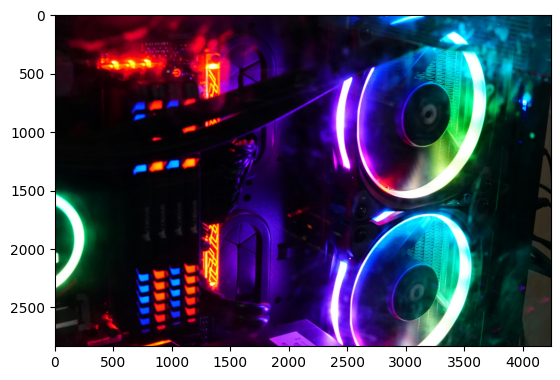

In [ ]:
img_r=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_r)

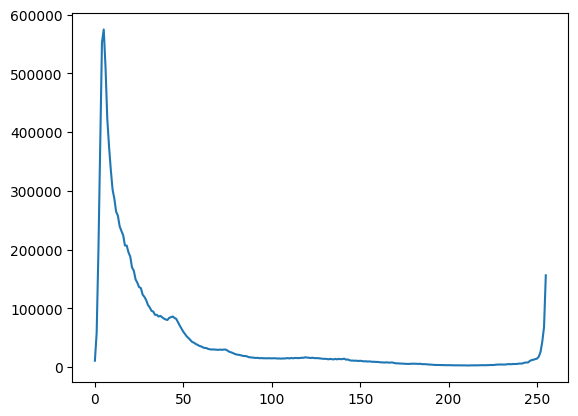

In [ ]:
hist =  cv2.calcHist([gray],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

In [ ]:
equalized = cv2.equalizeHist(gray)

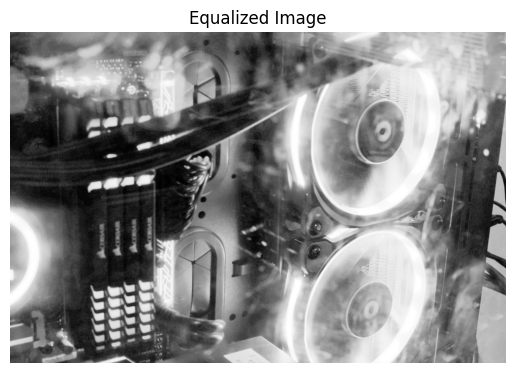

In [ ]:
plt.imshow(equalized, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')
plt.show()

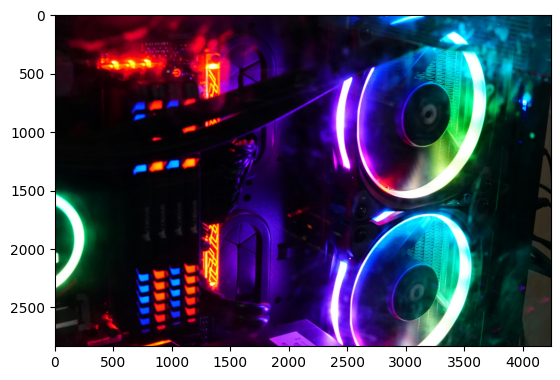

In [ ]:
img_r=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_r)

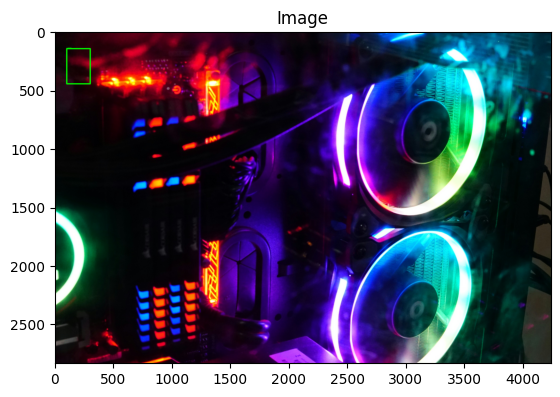

In [ ]:
crop = img[100:300, 150:450]
resized = cv2.resize(img, (700, 400))
resized = cv2.resize(img, None, fx=0.5, fy=0.5)
flipped_h=cv2.flip(img,1)
flipped_v=cv2.flip(img,0)
x1,y1 = 100,150
x2,y2= 300,450
cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 10)
cv2.putText(img, 'Label', (x1,y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Image")
plt.show()



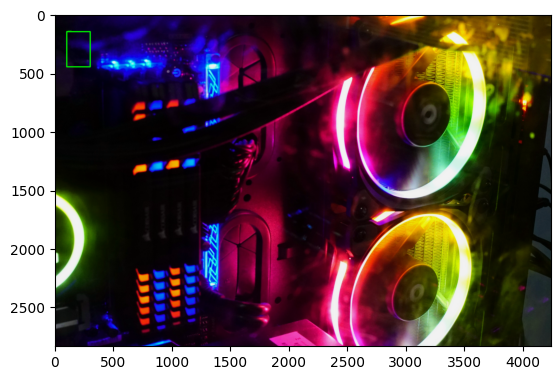

In [ ]:
img_float = img.astype(np.float32) / 255.0
img_bright=img_float * 0.95
img_bright = np.clip(img_bright, 0.0, 1.0)
img_bright = (img_bright * 255).astype(np.uint8)
plt.imshow(img_bright)
plt.show()

Webcam not found, create a test image instead


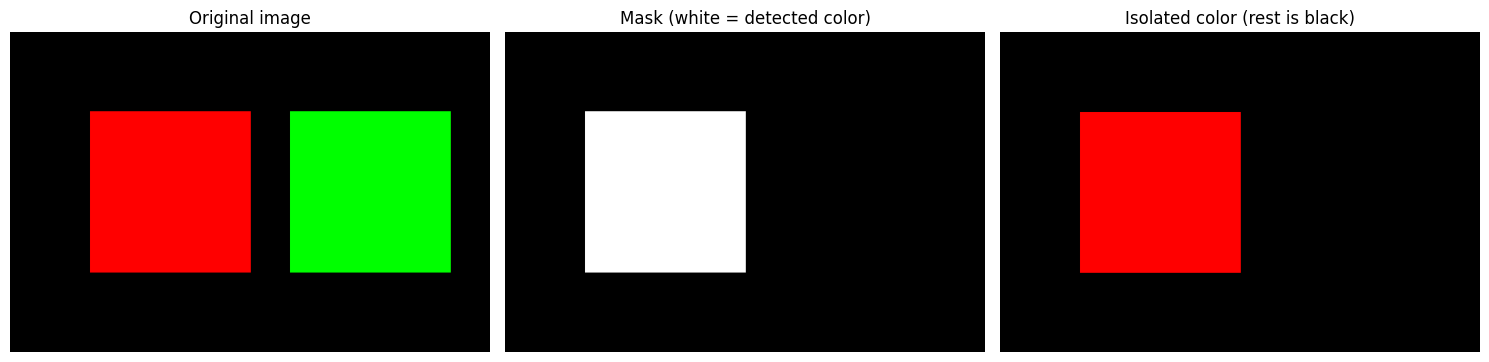

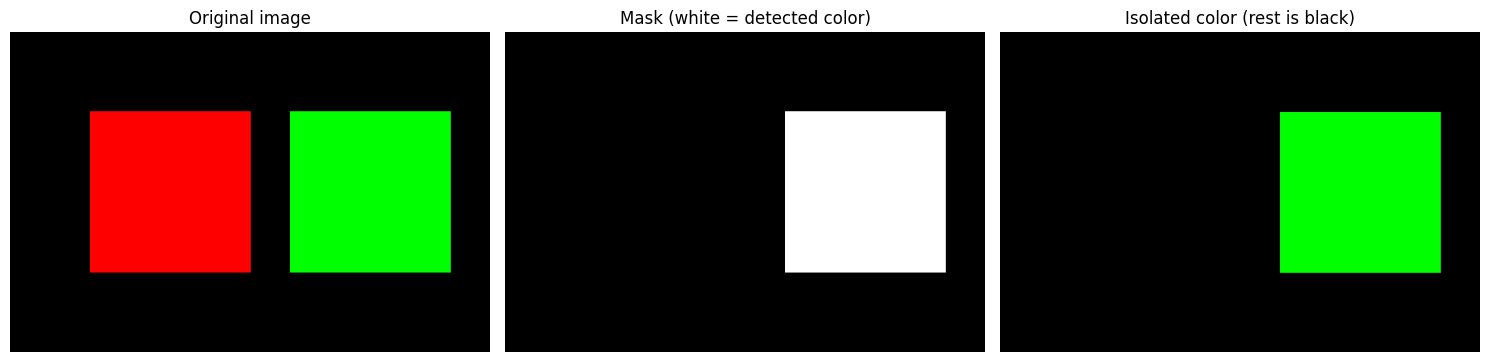

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# THE FUNCTION — isolate one color, black out everything else
# ============================================================

def isolate_color(img_bgr, lower_hsv, upper_hsv):

    # STEP 1: Convert BGR to HSV
    # OpenCV loads images in BGR by default
    # We convert to HSV so we can filter by color (Hue) easily
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # STEP 2: Create a mask
    # inRange checks every pixel — is its HSV value between lower and upper?
    # If YES  → that pixel becomes 255 (white) in the mask
    # If NO   → that pixel becomes 0   (black) in the mask
    # So mask is a pure black and white image
    mask = cv2.inRange(hsv, lower_hsv, upper_hsv)

    # STEP 3: Apply mask to original image
    # bitwise_and keeps a pixel ONLY if mask is white (255) at that location
    # Where mask is black (0), the pixel becomes black
    result = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

    return result, mask   # returning both so we can display them


# ============================================================
# SHOWING THE RESULT — 3 images side by side
# ============================================================

def show_result(img_bgr, result, mask):

    # matplotlib expects RGB, but OpenCV gives BGR
    # so we convert before displaying
    img_rgb    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    result_rgb = cv2.cvtColor(result,  cv2.COLOR_BGR2RGB)

    # Create a figure with 3 side-by-side panels
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_rgb)
    axes[0].set_title('Original image')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')   # mask is black & white
    axes[1].set_title('Mask (white = detected color)')
    axes[1].axis('off')

    axes[2].imshow(result_rgb)
    axes[2].set_title('Isolated color (rest is black)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


# ============================================================
# TEST IT — using a real image from your webcam
# OR a downloaded image
# ============================================================

# --- OPTION A: Use your webcam (takes one snapshot) ---
cap = cv2.VideoCapture(0)
ret, img_bgr = cap.read()   # capture one frame
cap.release()

if not ret:
    print("Webcam not found, create a test image instead")
    # Create a simple test image manually (red square on black background)
    img_bgr = np.zeros((400, 600, 3), dtype=np.uint8)
    cv2.rectangle(img_bgr, (100, 100), (300, 300), (0, 0, 255), -1)  # red square
    cv2.rectangle(img_bgr, (350, 100), (550, 300), (0, 255, 0), -1)  # green square


# --- Define HSV range for RED color ---
# In HSV, red wraps around — it appears near 0 AND near 180
# So we need TWO ranges for red and combine them

lower_red1 = np.array([0,   120, 70])   # lower red (near 0°)
upper_red1 = np.array([10,  255, 255])

lower_red2 = np.array([170, 120, 70])   # upper red (near 180°)
upper_red2 = np.array([180, 255, 255])

# Convert and create masks
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

# Combine both red masks into one
combined_mask = cv2.add(mask1, mask2)

# Apply combined mask
result = cv2.bitwise_and(img_bgr, img_bgr, mask=combined_mask)

# Show all 3 images
show_result(img_bgr, result, combined_mask)


# ============================================================
# ALSO TEST WITH GREEN (traffic light green)
# ============================================================

lower_green = np.array([40, 50, 50])
upper_green = np.array([80, 255, 255])

result_green, mask_green = isolate_color(img_bgr, lower_green, upper_green)
show_result(img_bgr, result_green, mask_green)




